In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
!pip install wfdb


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 83.0 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.26.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
ydata-profiling 4.18.1 requires pandas!=1.4.0,<3.0,>1.5, but you have pandas 3.0.0 which is incompatible.
google-colab 1.0.0 requires google-auth==2.38.0, but you have google-auth 2.47.0 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-

In [2]:
import wfdb
print("WFDB loaded successfully")


WFDB loaded successfully


In [3]:
import wfdb
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf


2026-02-17 13:40:52.791182: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771335652.974530      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771335653.026676      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771335653.465453      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771335653.465526      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771335653.465530      55 computation_placer.cc:177] computation placer alr

In [4]:
import os

base_path = "/kaggle/input/datasets/sangatichapla/mit-ecg-raw/mit-bih-arrhythmia-database-1.0.0/mit-bih-arrhythmia-database-1.0.0"

files = os.listdir(base_path)

records = list(set([f.split('.')[0] for f in files if f.endswith('.dat')]))

records = sorted(records)

print("Total records found:", len(records))
print(records)


Total records found: 48
['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', '209', '210', '212', '213', '214', '215', '217', '219', '220', '221', '222', '223', '228', '230', '231', '232', '233', '234']


In [5]:
window_size = 180

X = []
y = []

for rec in records:
    
    record = wfdb.rdrecord(os.path.join(base_path, rec))
    annotation = wfdb.rdann(os.path.join(base_path, rec), 'atr')
    
    signal = record.p_signal[:,0]
    beat_positions = annotation.sample
    beat_labels = annotation.symbol
    
    for pos, label in zip(beat_positions, beat_labels):
        if pos - window_size > 0 and pos + window_size < len(signal):
            beat = signal[pos-window_size : pos+window_size]
            X.append(beat)
            y.append(label)

X = np.array(X)
y = np.array(y)

print("Dataset shape:", X.shape)

Dataset shape: (112543, 360)


In [6]:
allowed_classes = ['N','V','A','L','R']

mask = np.isin(y, allowed_classes)

X = X[mask]
y = y[mask]

print("After filtering:", X.shape)


After filtering: (100011, 360)


In [7]:
label_map = {label:i for i,label in enumerate(np.unique(y))}

y = np.array([label_map[label] for label in y])

print(label_map)


{np.str_('A'): 0, np.str_('L'): 1, np.str_('N'): 2, np.str_('R'): 3, np.str_('V'): 4}


In [8]:
scaler = StandardScaler()
X = scaler.fit_transform(X)


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [10]:
from collections import Counter

print("Class distribution before balancing:")
print(Counter(y))


Class distribution before balancing:
Counter({np.int64(2): 75011, np.int64(1): 8071, np.int64(3): 7254, np.int64(4): 7129, np.int64(0): 2546})


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (80008, 360)
Test shape: (20003, 360)


In [13]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, class_weights))

print("Class weights:", class_weights)


Class weights: {np.int64(0): np.float64(7.855473735886107), np.int64(1): np.float64(2.4781787207681587), np.int64(2): np.float64(0.26665777896280496), np.int64(3): np.float64(2.757470273996209), np.int64(4): np.float64(2.8058214974574787)}


In [17]:
import tensorflow as tf
num_classes = len(np.unique(y))


model = tf.keras.Sequential([
    
    tf.keras.layers.Dense(256, activation='relu', input_shape=(360,)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),
    
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.4),
    
    tf.keras.layers.Dense(64, activation='relu'),
    
    tf.keras.layers.Dense(num_classes, activation='softmax')
])


In [18]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
# early_stop = tf.keras.callbacks.EarlyStopping(
#     monitor='val_loss',
#     patience=5,
#     restore_best_weights=True
# )


In [19]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    class_weight=class_weights,
    verbose=1
)


Epoch 1/20
501/501 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6044 - loss: 0.9668 - val_accuracy: 0.9193 - val_loss: 0.2853
Epoch 2/20
501/501 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8411 - loss: 0.3746 - val_accuracy: 0.9109 - val_loss: 0.2750
Epoch 3/20
501/501 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8698 - loss: 0.3035 - val_accuracy: 0.9347 - val_loss: 0.1969
Epoch 4/20
501/501 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8832 - loss: 0.2541 - val_accuracy: 0.9413 - val_loss: 0.1743
Epoch 5/20
501/501 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8894 - loss: 0.2462 - val_accuracy: 0.9556 - val_loss: 0.1422
Epoch 6/20
501/501 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9002 - loss: 0.2129 - val_accuracy: 0.9490 - val_loss: 0.1456
Epoch 7/20
501/501 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9111 - loss: 0.1967 - val_accuracy: 0.9559 - val_loss: 0.1340
Epoch 8/20
501/501 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9206 - loss: 0.1815 - val_accuracy: 0.

In [20]:
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_acc)


626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9704 - loss: 0.0882
Test Accuracy: 0.9692546129226685


In [21]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_pred = np.argmax(model.predict(X_test), axis=1)

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.94      0.71       509
           1       0.97      1.00      0.98      1614
           2       1.00      0.96      0.98     15003
           3       0.98      1.00      0.99      1451
           4       0.91      0.98      0.95      1426

    accuracy                           0.97     20003
   macro avg       0.89      0.98      0.92     20003
weighted avg       0.98      0.97      0.97     20003

Confusion Matrix:
[[  479     0    21     4     5]
 [    0  1606     6     0     2]
 [  344    51 14460    25   123]
 [    2     0     2  1446     1]
 [    8     4    13     4  1397]]


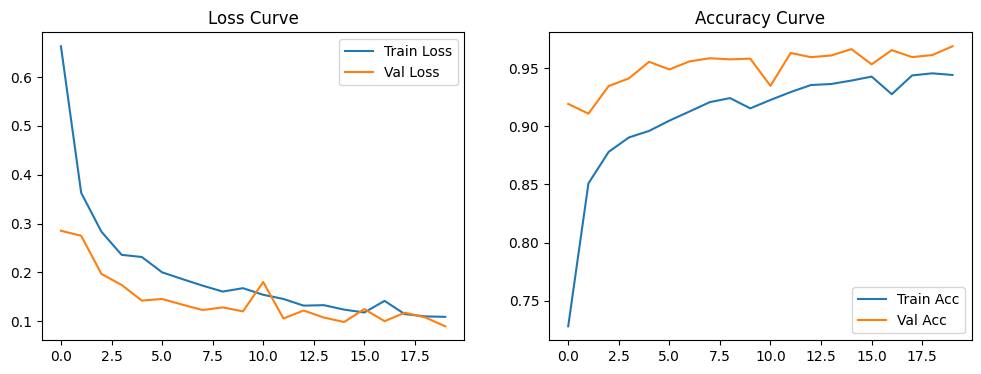

In [22]:

import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss Curve")

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Accuracy Curve")

plt.show()
